ML OBLIG1

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os; os.makedirs("figures", exist_ok=True)
import seaborn as sns

df = pd.read_csv("train.csv")
print(df.shape)
print(df.isna().sum().sum())

(21263, 82)
0


Q1.1.1


In [18]:
stats = df.describe().T
stats["cv"] = stats["std"] / stats["mean"]

cols = ["mean", "std", "min", "max", "cv"]
print(stats.sort_values("std", ascending=False).head(10)[cols])
print(stats.drop("critical_temp").sort_values("cv", ascending=False).head(10)[cols])

                          mean          std       min           max        cv
range_Density      8665.438818  4097.126831  0.000000  22588.571000  0.472812
wtd_gmean_Density  3117.241110  3975.122587  0.686245  22590.000000  1.275205
gmean_Density      3460.692235  3703.256370  1.429000  22590.000000  1.070091
wtd_mean_Density   5267.188547  3221.314506  1.429000  22590.000000  0.611581
mean_Density       6111.465214  2846.785185  1.429000  22590.000000  0.465811
wtd_range_Density  2902.736814  2398.471020  0.000000  22434.160000  0.826279
std_Density        3416.910784  1673.624915  0.000000  10724.374500  0.489806
wtd_std_Density    3319.170628  1611.799629  0.000000  10410.932005  0.485603
range_fie           572.222612   309.614442  0.000000   1304.500000  0.541073
wtd_range_fie       483.517264   224.042874  0.000000   1251.855072  0.463361
                                      mean          std       min  \
wtd_gmean_ThermalConductivity    27.308061    40.191150  0.022952   
wtd_

Q 1.1.2

skew raw:   0.8602232926106779
skew log:   -1.0042645868572804
skew log1p: -0.3173279075241499


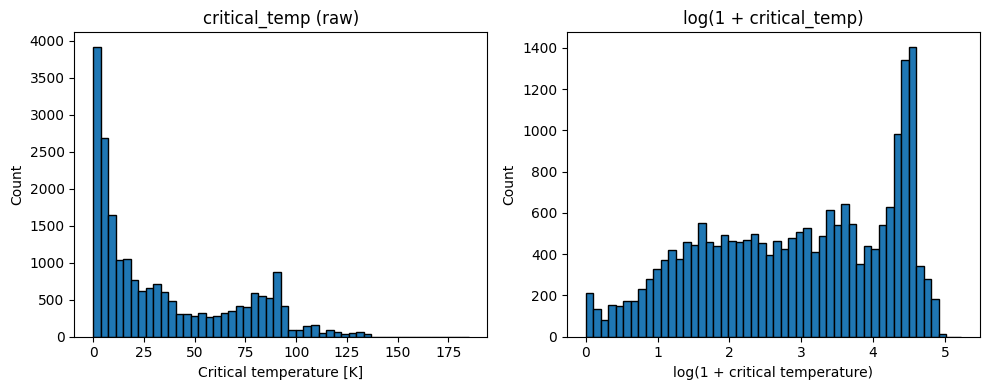

In [19]:
y = df["critical_temp"]
y_log = np.log1p(y)                  # log(1 + y)

print("skew raw:  ", y.skew())
print("skew log:  ", np.log(y).skew())
print("skew log1p:", y_log.skew())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(y, bins=50, edgecolor="black")
axes[0].set(title="critical_temp (raw)", xlabel="Critical temperature [K]", ylabel="Count")
axes[1].hist(y_log, bins=50, edgecolor="black")
axes[1].set(title="log(1 + critical_temp)", xlabel="log(1 + critical temperature)", ylabel="Count")
plt.tight_layout()
plt.savefig("figures/q112_target_distribution.pdf", bbox_inches="tight")
plt.show()

Q 1.2.1

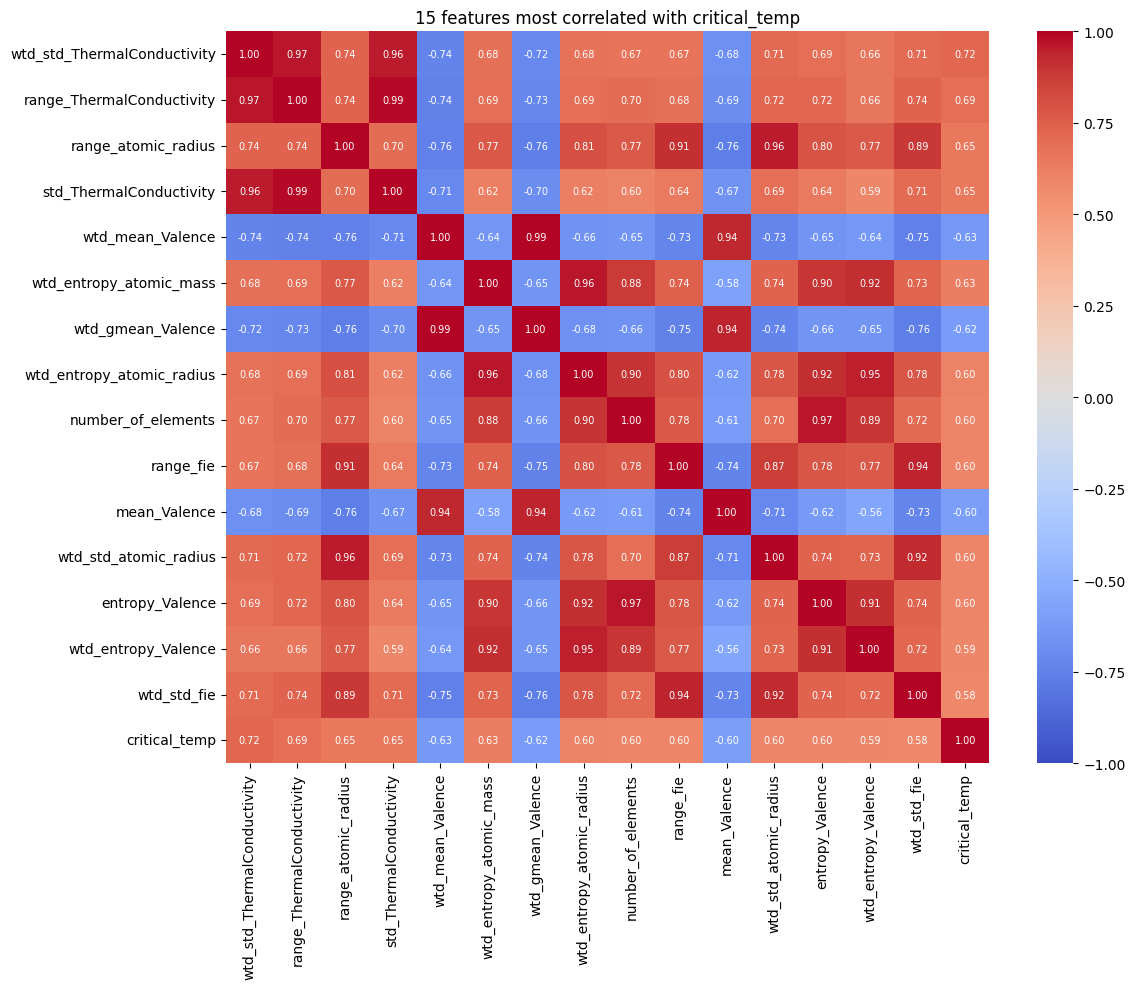

In [20]:
corr = df.corr()
target_corr = corr["critical_temp"].drop("critical_temp")
top15 = target_corr.abs().sort_values(ascending=False).head(15).index

cols = list(top15) + ["critical_temp"]
plt.figure(figsize=(12, 10))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("15 features most correlated with critical_temp")
plt.tight_layout()
plt.savefig("figures/q121_heatmap.pdf", bbox_inches="tight")
plt.show()

Q 1.2.2

In [21]:
print(target_corr.sort_values(ascending=False).head(5))
print(target_corr.sort_values().head(5))

wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_entropy_atomic_mass        0.626930
Name: critical_temp, dtype: float64
wtd_mean_Valence    -0.632401
wtd_gmean_Valence   -0.615653
mean_Valence        -0.600085
gmean_Valence       -0.573068
gmean_Density       -0.541684
Name: critical_temp, dtype: float64


Q 1.2.3

In [22]:
fc = df.drop(columns="critical_temp").corr()
mask = np.triu(np.ones(fc.shape, dtype=bool), k=1)
pairs = fc.where(mask).stack()
high = pairs[pairs.abs() > 0.9].sort_values(key=abs, ascending=False)

print(len(high), "pairs with |r| > 0.9")
print(high.head(10))

74 pairs with |r| > 0.9
entropy_fie                entropy_atomic_radius      0.997739
wtd_mean_Valence           wtd_gmean_Valence          0.994939
entropy_fie                entropy_Valence            0.992726
wtd_mean_fie               wtd_gmean_fie              0.992331
mean_Valence               gmean_Valence              0.989911
entropy_atomic_radius      entropy_Valence            0.989546
range_ThermalConductivity  std_ThermalConductivity    0.987867
range_FusionHeat           std_FusionHeat             0.984574
range_fie                  std_fie                    0.981628
wtd_mean_atomic_radius     wtd_gmean_atomic_radius    0.980107
dtype: float64


Q 1.2.4

In [23]:
log_corr = df.drop(columns="critical_temp").corrwith(np.log1p(df["critical_temp"]))
both = pd.DataFrame({"raw": target_corr, "log1p": log_corr})
both = both.reindex(both["raw"].abs().sort_values(ascending=False).index)

print(both.head(5))    # strongest
print(both.tail(5))    # weakest

                                  raw     log1p
wtd_std_ThermalConductivity  0.721271  0.732366
range_ThermalConductivity    0.687654  0.717480
range_atomic_radius          0.653759  0.733356
std_ThermalConductivity      0.653632  0.677253
wtd_mean_Valence            -0.632401 -0.687750
                                  raw     log1p
wtd_gmean_ElectronAffinity  -0.107359 -0.128132
mean_atomic_radius           0.105273  0.048967
mean_fie                     0.102268  0.128769
entropy_ThermalConductivity  0.085862  0.113650
gmean_fie                   -0.025103 -0.018078


# Q 1.3.1 and 1.3.2 Gradient Decent

In [29]:
def gradient_descent(X, y, lr=0.1, n_iter=1000):
    """Linear regression by batch gradient descent. X: (n, d), y: (n,)."""
    n, d = X.shape
    w, b = np.zeros(d), 0.0
    cost_history = []
    for _ in range(n_iter):
        # matmul gave me errors because im on mac, seems to be a know issue, simply just silencing the errors.
        with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
            error = X @ w + b - y
            grad_w = (X.T @ error) / n
        cost_history.append((error ** 2).mean() / 2)
        w -= lr * grad_w
        b -= lr * error.mean()
    if not np.isfinite(cost_history[-1]):
        print("Warning: gradient descent diverged (cost is not finite)")
    return w, b, cost_history

WEAK, STRONG = "gmean_fie", "wtd_std_ThermalConductivity"
y_target = y_log.values # from Q1.1.2

results = {}
for feat in [WEAK, STRONG]:
    x = df[feat].values
    mu, sigma = x.mean(), x.std()
    z = ((x - mu) / sigma).reshape(-1, 1)
    w, b, cost = gradient_descent(z, y_target)
    pred = z @ w + b
    r2 = 1 - ((y_target - pred) ** 2).sum() / ((y_target - y_target.mean()) ** 2).sum()
    results[feat] = (w[0], b, cost, mu, sigma)
    print(f"{feat}: coef = {w[0]:.4f}, intercept = {b:.4f}, "
          f"final cost = {cost[-1]:.4f}, R2 = {r2:.4f}")
    print("   closed-form check (slope, intercept):", np.polyfit(z.ravel(), y_target, 1))

x_raw = df[WEAK].values.reshape(-1, 1)
_, _, cost_raw = gradient_descent(x_raw, y_target, lr=0.1, n_iter=5)
print(cost_raw)

gmean_fie: coef = -0.0233, intercept = 2.9138, final cost = 0.8310, R2 = 0.0003
   closed-form check (slope, intercept): [-0.02330964  2.91376434]
wtd_std_ThermalConductivity: coef = 0.9443, intercept = 2.9138, final cost = 0.3854, R2 = 0.5364
   closed-form check (slope, intercept): [0.94431201 2.91376434]
[np.float64(5.076287049917525), np.float64(12676121745.638195), np.float64(3.834455303075394e+19), np.float64(1.1599010933584256e+29), np.float64(3.508635360268845e+38)]


Q 1.3.4

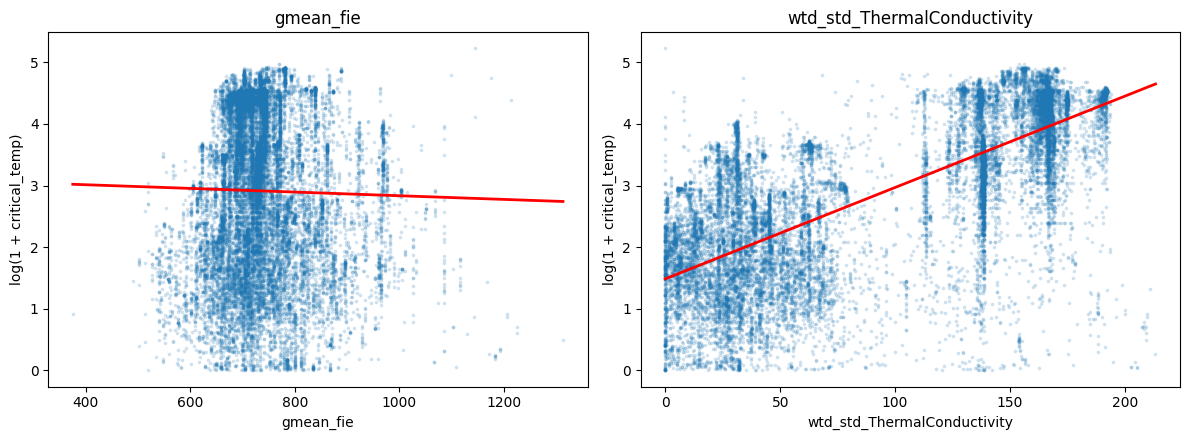

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, feat in zip(axes, [WEAK, STRONG]):
    w, b, _, mu, sigma = results[feat]
    x = df[feat].values
    xs = np.linspace(x.min(), x.max(), 100)
    ax.scatter(x, y_target, s=3, alpha=0.15)
    ax.plot(xs, w * (xs - mu) / sigma + b, color="red", lw=2)
    ax.set(title=feat, xlabel=feat, ylabel="log(1 + critical_temp)")
plt.tight_layout()
plt.savefig("figures/q134_regression_lines.png", dpi=200, bbox_inches="tight")
plt.show()

Q 1.4

In [31]:
from sklearn.model_selection import KFold

def metrics(y_true, y_pred):
    mse = ((y_true - y_pred) ** 2).mean()
    r2 = 1 - ((y_true - y_pred) ** 2).sum() / ((y_true - y_true.mean()) ** 2).sum()
    return mse, np.sqrt(mse), r2

kf = KFold(n_splits=5, shuffle=True, random_state=42)
folds = list(kf.split(df)) # saved so 1.5 uses the same splits

def evaluate_folds(features, lr=0.1, n_iter=1000):
    X_all, y_all = df[features].values, y_log.values
    y_kelvin = df["critical_temp"].values
    rows = []
    for k, (tr, te) in enumerate(folds, start=1):
        mu, sigma = X_all[tr].mean(axis=0), X_all[tr].std(axis=0) # train set only
        Z_tr, Z_te = (X_all[tr] - mu) / sigma, (X_all[te] - mu) / sigma
        w, b, _ = gradient_descent(Z_tr, y_all[tr], lr, n_iter)
        with np.errstate(all="ignore"):
            pred_tr, pred_te = Z_tr @ w + b, Z_te @ w + b
        mse, rmse, r2 = metrics(y_all[te], pred_te)
        _, rmse_tr, r2_tr = metrics(y_all[tr], pred_tr)
        _, rmse_K, r2_K = metrics(y_kelvin[te], np.expm1(pred_te))
        rows.append({"fold": k, "mse": mse, "rmse": rmse, "r2": r2,
                     "rmse_train": rmse_tr, "r2_train": r2_tr,
                     "rmse_K": rmse_K, "r2_K": r2_K})
    return pd.DataFrame(rows).set_index("fold")

for feat in [STRONG, WEAK]:
    res = evaluate_folds([feat])
    print(f"\n=== {feat} ===")
    with pd.option_context("display.float_format", "{:.4f}".format):
        print(res)
    with pd.option_context("display.float_format", "{:.3e}".format):
        print(res.agg(["mean", "var"]))


=== wtd_std_ThermalConductivity ===
        mse   rmse     r2  rmse_train  r2_train  rmse_K   r2_K
fold                                                          
1    0.7817 0.8841 0.5320      0.8764    0.5374 24.6472 0.4722
2    0.7850 0.8860 0.5368      0.8760    0.5362 25.8107 0.4455
3    0.7645 0.8744 0.5257      0.8789    0.5388 24.2792 0.4732
4    0.7611 0.8724 0.5485      0.8794    0.5332 25.9009 0.4414
5    0.7629 0.8734 0.5373      0.8791    0.5361 25.4590 0.4559
           mse      rmse        r2  rmse_train  r2_train    rmse_K      r2_K
mean 7.710e-01 8.781e-01 5.361e-01   8.780e-01 5.364e-01 2.522e+01 4.577e-01
var  1.294e-04 4.183e-05 7.014e-05   2.654e-06 4.306e-06 5.207e-01 2.169e-04

=== gmean_fie ===
        mse   rmse      r2  rmse_train  r2_train  rmse_K    r2_K
fold                                                            
1    1.6707 1.2926 -0.0002      1.2884    0.0004 37.7075 -0.2352
2    1.6956 1.3021 -0.0005      1.2859    0.0005 38.9199 -0.2607
3    1.6119 

Q 1.5

In [32]:
ALL = [c for c in df.columns if c != "critical_temp"]
eig = np.linalg.eigvalsh(fc.values)        # fc = 81x81 feature correlation matrix from Q1.2.3
print(f"lambda_max = {eig.max():.2f}, lambda_min = {eig.min():.3e}")
lr_multi = 1 / eig.max()
print(f"learning rate = {lr_multi:.4f}")

lambda_max = 31.53, lambda_min = 4.960e-05
learning rate = 0.0317


In [33]:
X_all, y_all, y_kelvin = df[ALL].values, y_log.values, df["critical_temp"].values
rows, ref, coefs_gd, coefs_ols = [], [], [], []

for k, (tr, te) in enumerate(folds, start=1):
    mu, sigma = X_all[tr].mean(axis=0), X_all[tr].std(axis=0)
    Z_tr, Z_te = (X_all[tr] - mu) / sigma, (X_all[te] - mu) / sigma
    w, b, cost = gradient_descent(Z_tr, y_all[tr], lr=lr_multi, n_iter=5000)

    A_tr, A_te = np.c_[Z_tr, np.ones(len(tr))], np.c_[Z_te, np.ones(len(te))]
    with np.errstate(all="ignore"):
        pred_tr, pred_te = Z_tr @ w + b, Z_te @ w + b
        beta_log = np.linalg.lstsq(A_tr, y_all[tr], rcond=None)[0]      # exact OLS, log target
        beta_raw = np.linalg.lstsq(A_tr, y_kelvin[tr], rcond=None)[0]   # exact OLS, raw target
        ols_log, ols_raw = A_te @ beta_log, A_te @ beta_raw

    mse, rmse, r2 = metrics(y_all[te], pred_te)
    _, rmse_tr, r2_tr = metrics(y_all[tr], pred_tr)
    _, rmse_K, r2_K = metrics(y_kelvin[te], np.expm1(pred_te))
    rows.append({"fold": k, "mse": mse, "rmse": rmse, "r2": r2,
                 "rmse_train": rmse_tr, "r2_train": r2_tr, "rmse_K": rmse_K, "r2_K": r2_K})

    _, _, r2_ols = metrics(y_all[te], ols_log)
    _, rK_log, r2K_log = metrics(y_kelvin[te], np.expm1(ols_log))
    _, rK_raw, r2K_raw = metrics(y_kelvin[te], ols_raw)
    ref.append({"fold": k, "r2_ols_log": r2_ols, "rmse_K_ols_log": rK_log,
                "r2_K_ols_log": r2K_log, "rmse_K_ols_raw": rK_raw, "r2_K_ols_raw": r2K_raw})

    coefs_gd.append(w); coefs_ols.append(beta_log[:-1])
    if k == 1:
        cost_multi, pred_multi = cost, pred_te

res_multi = pd.DataFrame(rows).set_index("fold")
res_ref = pd.DataFrame(ref).set_index("fold")
with pd.option_context("display.float_format", "{:.4f}".format, "display.width", 200):
    print(res_multi); print(res_ref)
with pd.option_context("display.float_format", "{:.3e}".format, "display.width", 200):
    print(res_multi.agg(["mean", "var"]))

show = ["wtd_mean_Valence", "wtd_gmean_Valence", "entropy_fie", "entropy_atomic_radius", STRONG]
idx = [ALL.index(f) for f in show]
with pd.option_context("display.float_format", "{:.3f}".format, "display.width", 200):
    print("GD coefficients per fold:");  print(pd.DataFrame(np.array(coefs_gd)[:, idx], columns=show, index=range(1, 6)))
    print("OLS coefficients per fold:"); print(pd.DataFrame(np.array(coefs_ols)[:, idx], columns=show, index=range(1, 6)))

        mse   rmse     r2  rmse_train  r2_train  rmse_K   r2_K
fold                                                          
1    0.3987 0.6315 0.7613      0.6374    0.7553 18.1512 0.7138
2    0.4164 0.6453 0.7543      0.6342    0.7569 18.5269 0.7143
3    0.4128 0.6425 0.7439      0.6345    0.7597 18.0670 0.7083
4    0.4032 0.6350 0.7608      0.6366    0.7554 18.6369 0.7108
5    0.4074 0.6383 0.7529      0.6358    0.7574 18.5157 0.7122
      r2_ols_log  rmse_K_ols_log  r2_K_ols_log  rmse_K_ols_raw  r2_K_ols_raw
fold                                                                        
1         0.7663         17.8930        0.7219         17.3784        0.7376
2         0.7630         18.2166        0.7238         17.8524        0.7347
3         0.7505         17.7074        0.7198         17.6396        0.7219
4         0.7675         18.2585        0.7224         17.6914        0.7394
5         0.7599         18.1798        0.7225         17.5620        0.7411
           mse      

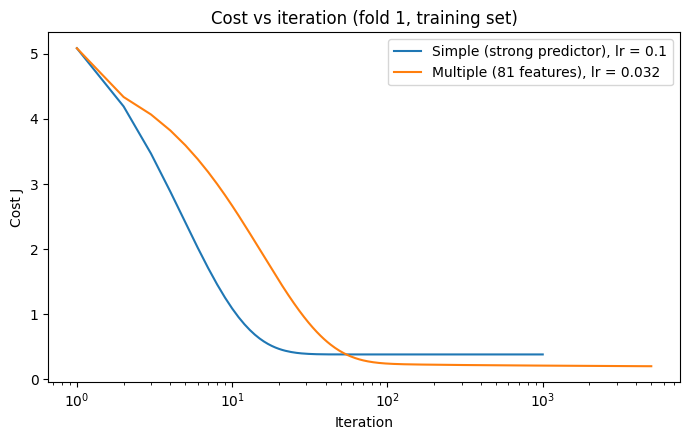

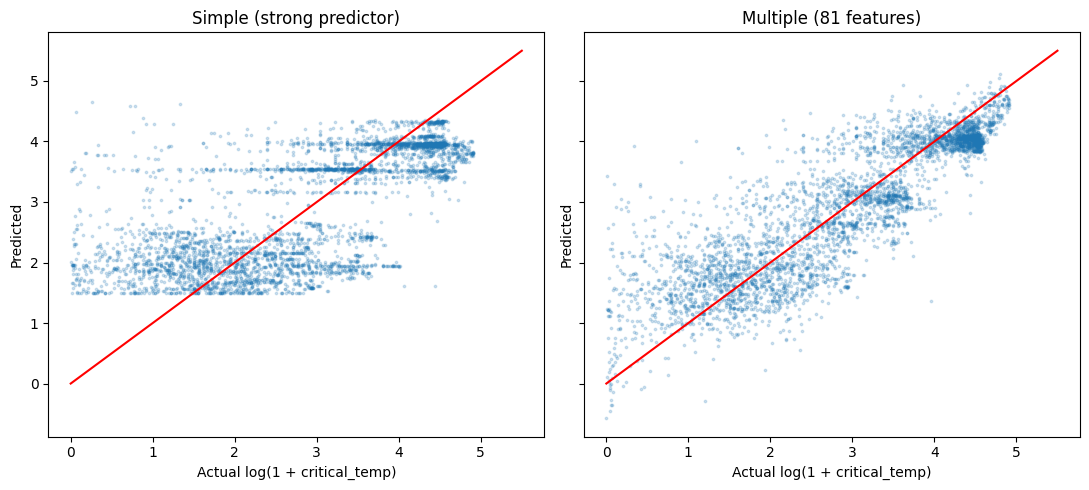

In [34]:
tr, te = folds[0]
x = df[[STRONG]].values
mu_s, sd_s = x[tr].mean(axis=0), x[tr].std(axis=0)
w_s, b_s, cost_simple = gradient_descent((x[tr] - mu_s) / sd_s, y_all[tr])
with np.errstate(all="ignore"):
    pred_simple = ((x[te] - mu_s) / sd_s) @ w_s + b_s

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(cost_simple) + 1), cost_simple, label="Simple (strong predictor), lr = 0.1")
plt.plot(range(1, len(cost_multi) + 1), cost_multi, label=f"Multiple (81 features), lr = {lr_multi:.3f}")
plt.xscale("log"); plt.xlabel("Iteration"); plt.ylabel("Cost J"); plt.legend()
plt.title("Cost vs iteration (fold 1, training set)")
plt.tight_layout()
plt.savefig("figures/q153_cost.pdf", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, pred, name in zip(axes, [pred_simple, pred_multi], ["Simple (strong predictor)", "Multiple (81 features)"]):
    ax.scatter(y_all[te], pred, s=3, alpha=0.2)
    ax.plot([0, 5.5], [0, 5.5], color="red", lw=1.5)
    ax.set(title=name, xlabel="Actual log(1 + critical_temp)", ylabel="Predicted")
plt.tight_layout()
plt.savefig("figures/q153_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

Q 2.1

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

tr, te = folds[0]
X_tr, X_te = df[ALL].iloc[tr], df[ALL].iloc[te]
y_tr, y_te = y_log.iloc[tr], y_log.iloc[te]

rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42).fit(X_tr, y_tr)
print(f"RF, 81 features: R2 train = {rf.score(X_tr, y_tr):.4f}, R2 test = {rf.score(X_te, y_te):.4f}")
perm = permutation_importance(rf, X_te, y_te, n_repeats=5, random_state=42, n_jobs=-1)

imp = pd.DataFrame({
    "abs_corr": log_corr.abs(),
    "rf_impurity": pd.Series(rf.feature_importances_, index=ALL),
    "permutation": pd.Series(perm.importances_mean, index=ALL),
}).loc[ALL]

for col in ["abs_corr", "rf_impurity", "permutation"]:
    print(f"\nTop 10 by {col}:")
    print(imp[col].sort_values(ascending=False).head(10))

RF, 81 features: R2 train = 0.9806, R2 test = 0.9295


/Users/simen/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Top 10 by abs_corr:
range_atomic_radius            0.733356
wtd_std_ThermalConductivity    0.732366
range_ThermalConductivity      0.717480
wtd_std_atomic_radius          0.692267
wtd_mean_Valence               0.687750
wtd_entropy_atomic_mass        0.681841
range_fie                      0.681790
std_ThermalConductivity        0.677253
entropy_Valence                0.676527
wtd_gmean_Valence              0.676401
Name: abs_corr, dtype: float64

Top 10 by rf_impurity:
range_ThermalConductivity        0.602618
mean_Density                     0.052460
wtd_gmean_ThermalConductivity    0.037898
wtd_mean_atomic_mass             0.015474
wtd_gmean_ElectronAffinity       0.015472
wtd_std_ElectronAffinity         0.014017
wtd_mean_ThermalConductivity     0.010259
range_atomic_radius              0.009218
wtd_gmean_Valence                0.008605
std_ThermalConductivity          0.008110
Name: rf_impurity, dtype: float64

Top 10 by permutation:
range_ThermalConductivity        0.830786
mean

In [38]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

dist = 1 - fc.abs().values # fc = feature correlation matrix from Q1.2.3
np.fill_diagonal(dist, 0)
link = linkage(squareform(dist, checks=False), method="complete")
imp["cluster"] = pd.Series(fcluster(link, t=0.1, criterion="distance"), index=fc.columns)
print("clusters:", imp["cluster"].nunique(), "from", len(ALL), "features")

reps = imp.groupby("cluster")["abs_corr"].idxmax().tolist() # one representative per cluster
rf2 = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42).fit(X_tr[reps], y_tr)
print(f"RF, {len(reps)} representatives: R2 test = {rf2.score(X_te[reps], y_te):.4f}")

perm2 = permutation_importance(rf2, X_te[reps], y_te, n_repeats=5, random_state=42, n_jobs=-1)
final = pd.Series(perm2.importances_mean, index=reps).sort_values(ascending=False)
TOP10 = final.head(10).index.tolist()

print("\nFinal top 10 (permutation importance, one feature per cluster):")
for f in TOP10:
    others = [m for m in imp.index[imp["cluster"] == imp.loc[f, "cluster"]] if m != f]
    print(f"  {f}: {final[f]:.4f}   stands for: {others}")

clusters: 48 from 81 features
RF, 48 representatives: R2 test = 0.9275

Final top 10 (permutation importance, one feature per cluster):
  range_atomic_radius: 0.4789   stands for: ['std_atomic_radius', 'wtd_std_atomic_radius']
  wtd_range_Valence: 0.2592   stands for: []
  wtd_mean_Valence: 0.0946   stands for: ['mean_Valence', 'gmean_Valence', 'wtd_gmean_Valence']
  wtd_mean_ThermalConductivity: 0.0739   stands for: []
  mean_Density: 0.0651   stands for: []
  wtd_gmean_Density: 0.0332   stands for: ['gmean_Density']
  wtd_std_ThermalConductivity: 0.0265   stands for: ['range_ThermalConductivity', 'std_ThermalConductivity']
  wtd_gmean_atomic_mass: 0.0252   stands for: ['wtd_mean_atomic_mass']
  wtd_entropy_FusionHeat: 0.0188   stands for: []
  wtd_std_ElectronAffinity: 0.0166   stands for: []


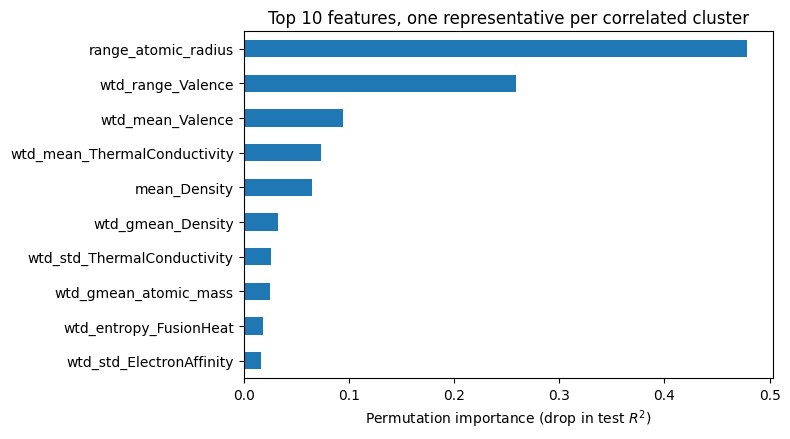

In [39]:
plt.figure(figsize=(8, 4.5))
final.head(10).iloc[::-1].plot.barh()
plt.xlabel("Permutation importance (drop in test $R^2$)")
plt.title("Top 10 features, one representative per correlated cluster")
plt.tight_layout()
plt.savefig("figures/q21_importance.pdf", bbox_inches="tight")
plt.show()